# Task : House Price Prediction


## Objective
Predict house prices using property features such as size, bedrooms, and location.

## Dataset
California Housing Dataset (built into scikit-learn) — similar to the Kaggle House Price dataset.
*(You can also use the Kaggle 'House Prices: Advanced Regression Techniques' dataset)*

## Step 1: Install & Import Libraries

In [19]:
!pip install scikit-learn pandas numpy matplotlib seaborn xgboost

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load Dataset

In [21]:
# Using California Housing dataset (built-in, no download needed)
# Structure similar to Kaggle House Price datasets
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.rename(columns={'MedHouseVal': 'Price'}, inplace=True)  # target column

# Feature descriptions:
# MedInc       — median income in block group
# HouseAge     — median house age
# AveRooms     — average rooms per household
# AveBedrms    — average bedrooms per household
# Population   — block group population
# AveOccup     — average occupancy
# Latitude     — block group latitude
# Longitude    — block group longitude
# Price        — median house value (in $100K)

print(f'Shape: {df.shape}')
print('\nFirst 5 rows:')
df.head()

Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [22]:
print('--- Dataset Info ---')
df.info()
print('\n--- Summary Statistics ---')
df.describe()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

--- Summary Statistics ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Step 3: Exploratory Data Analysis (EDA)

In [23]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

Total missing: 0


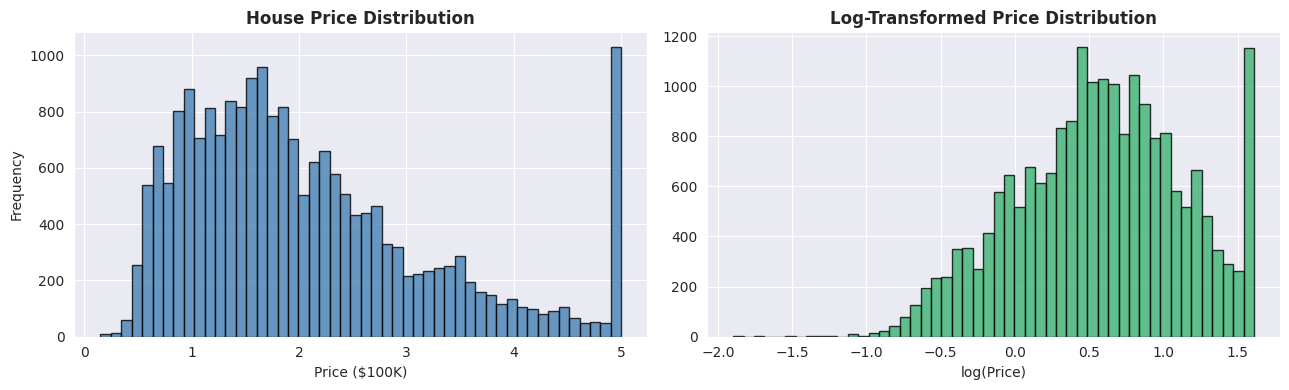

In [24]:
# Distribution of house prices
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('House Price Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price ($100K)')
axes[0].set_ylabel('Frequency')

# Log-transformed for normality
axes[1].hist(np.log(df['Price']), bins=50, color='mediumseagreen',
             edgecolor='black', alpha=0.8)
axes[1].set_title('Log-Transformed Price Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

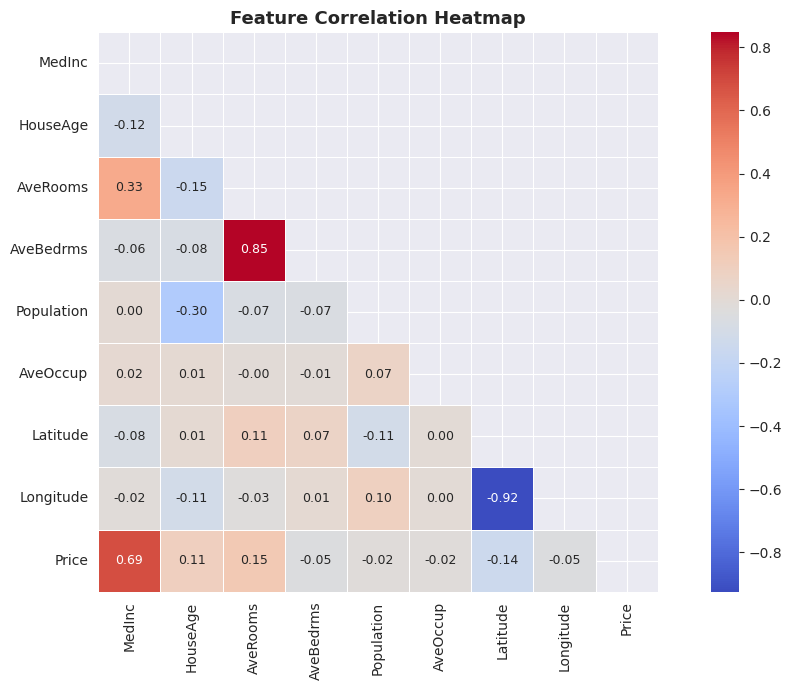

In [25]:
# Correlation heatmap
plt.figure(figsize=(11, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

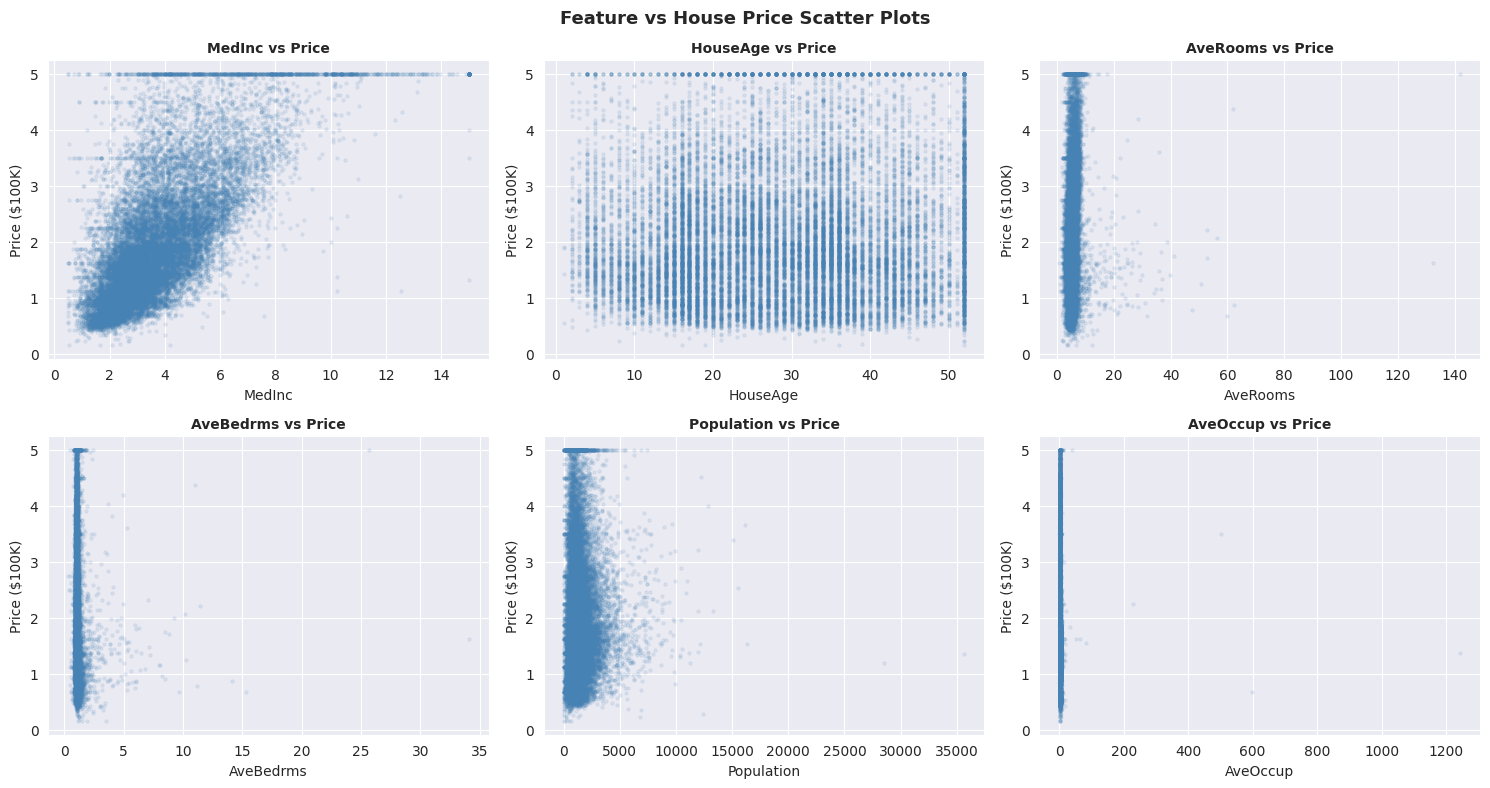

In [26]:
# Scatter plots: key features vs price
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features_to_plot = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df['Price'], alpha=0.1, color='steelblue', s=5)
    ax.set_xlabel(feat)
    ax.set_ylabel('Price ($100K)')
    ax.set_title(f'{feat} vs Price', fontsize=10, fontweight='bold')

plt.suptitle('Feature vs House Price Scatter Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

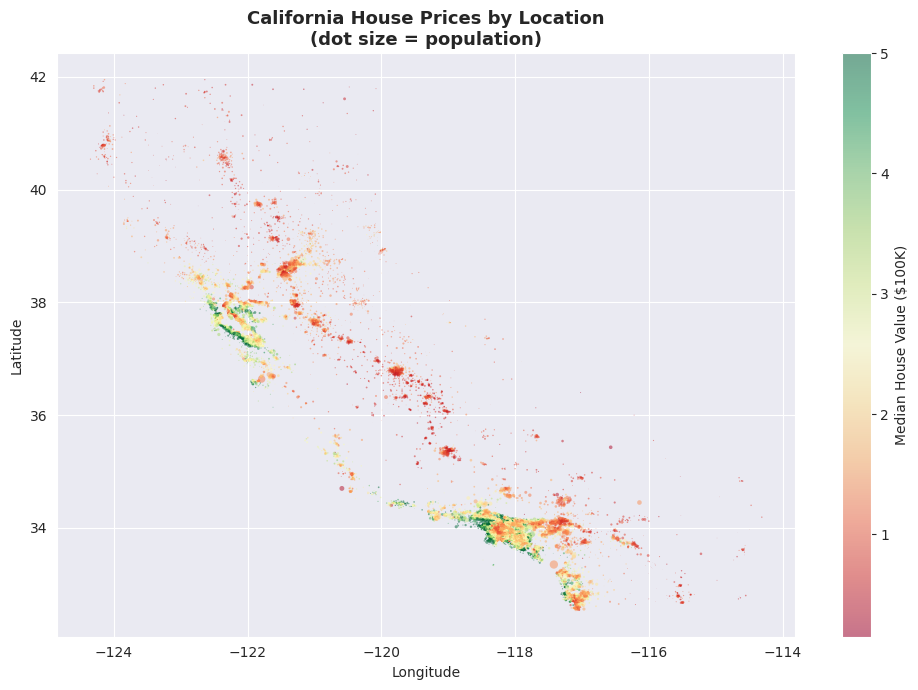

In [27]:
# Geographic visualization of prices
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Longitude'], df['Latitude'],
                      c=df['Price'], cmap='RdYlGn', alpha=0.5,
                      s=df['Population']/1000, linewidth=0)
plt.colorbar(scatter, label='Median House Value ($100K)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California House Prices by Location\n(dot size = population)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Feature Engineering & Preprocessing

In [28]:
data = df.copy()

# Feature: rooms per person
data['RoomsPerPerson'] = data['AveRooms'] / data['AveOccup']

# Feature: bedrooms ratio
data['BedroomRatio'] = data['AveBedrms'] / data['AveRooms']

# Remove extreme outliers in price (cap at 99th percentile)
q99 = data['Price'].quantile(0.99)
data = data[data['Price'] <= q99]

print(f'Dataset size after outlier removal: {len(data)}')

feature_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                'Population', 'AveOccup', 'Latitude', 'Longitude',
                'RoomsPerPerson', 'BedroomRatio']

X = data[feature_cols]
y = data['Price']

print(f'Features used: {feature_cols}')

Dataset size after outlier removal: 20640
Features used: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerPerson', 'BedroomRatio']


## Step 5: Train/Test Split & Scaling

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

Training samples : 16512
Testing samples  : 4128


## Step 6: Train Models

In [30]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

# Gradient Boosting Regressor
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=4, random_state=42)
gb.fit(X_train, y_train)  # GB doesn't require scaling
gb_preds = gb.predict(X_test)

print('Models trained successfully!')

Models trained successfully!


## Step 7: Evaluate Models

In [31]:
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n{name}')
    print(f'  MAE  : ${mae*100000:.0f}  ({mae:.4f} in $100K units)')
    print(f'  RMSE : ${rmse*100000:.0f}  ({rmse:.4f} in $100K units)')
    print(f'  R²   : {r2:.4f}')
    return mae, rmse, r2

lr_metrics = evaluate_model('Linear Regression',     y_test, lr_preds)
gb_metrics = evaluate_model('Gradient Boosting',     y_test, gb_preds)


Linear Regression
  MAE  : $48616  (0.4862 in $100K units)
  RMSE : $67535  (0.6753 in $100K units)
  R²   : 0.6519

Gradient Boosting
  MAE  : $32472  (0.3247 in $100K units)
  RMSE : $48718  (0.4872 in $100K units)
  R²   : 0.8189


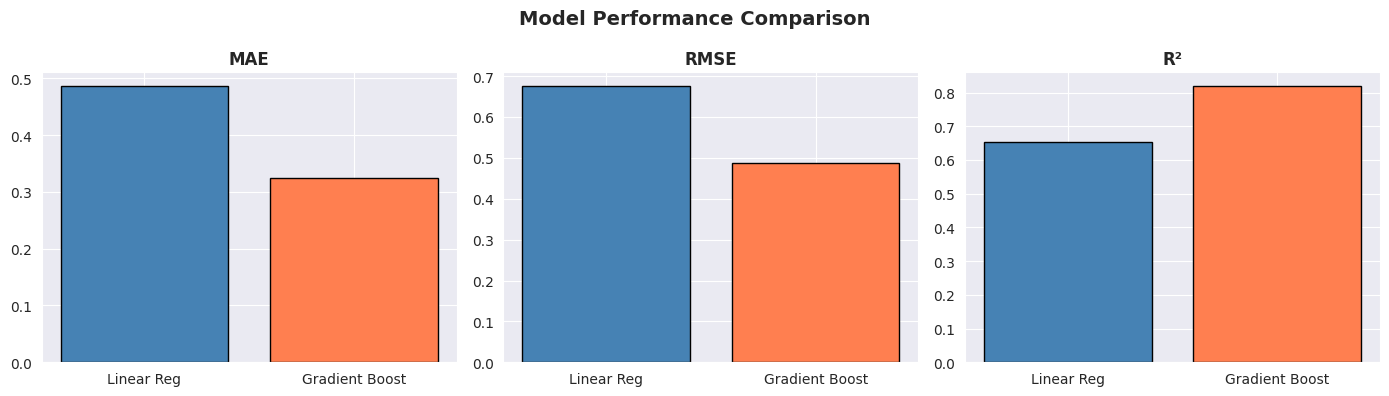

In [32]:
# Comparison bar chart
metric_names = ['MAE', 'RMSE', 'R²']
lr_vals = list(lr_metrics)
gb_vals = list(gb_metrics)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, m, lv, gv in zip(axes, metric_names, lr_vals, gb_vals):
    ax.bar(['Linear Reg', 'Gradient Boost'], [lv, gv],
           color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(m, fontsize=12, fontweight='bold')
plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: Visualize Predictions

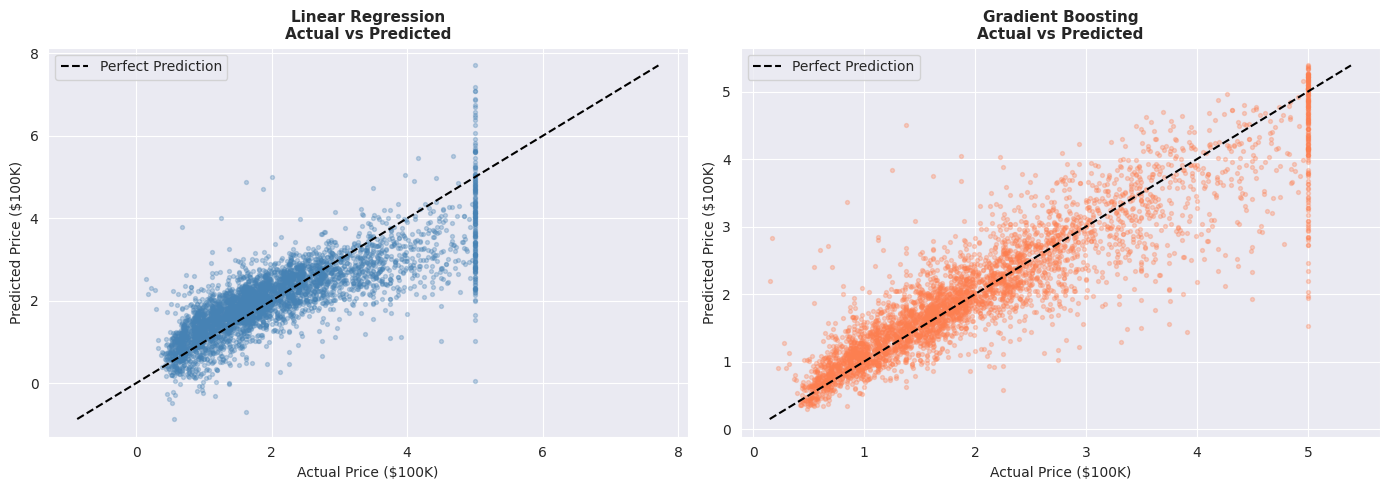

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name, color in zip(
        axes,
        [lr_preds, gb_preds],
        ['Linear Regression', 'Gradient Boosting'],
        ['steelblue', 'coral']):
    ax.scatter(y_test, preds, alpha=0.3, s=8, color=color)
    # Perfect prediction line
    mn, mx = min(y_test.min(), preds.min()), max(y_test.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlabel('Actual Price ($100K)')
    ax.set_ylabel('Predicted Price ($100K)')
    ax.set_title(f'{name}\nActual vs Predicted', fontsize=11, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

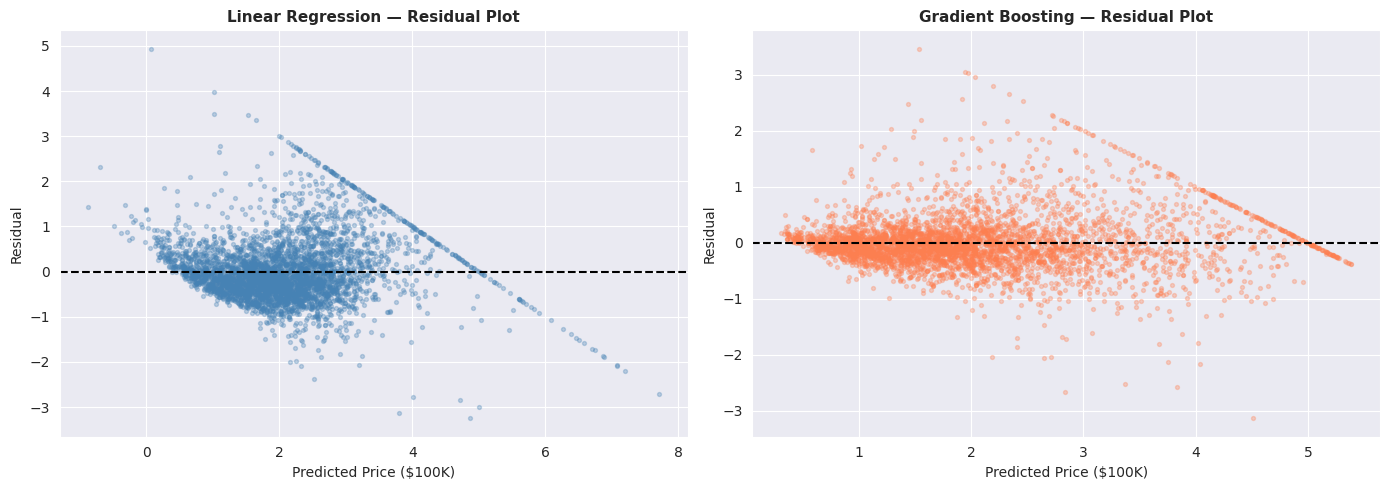

In [34]:
# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name, color in zip(
        axes,
        [lr_preds, gb_preds],
        ['Linear Regression', 'Gradient Boosting'],
        ['steelblue', 'coral']):
    residuals = y_test.values - preds
    ax.scatter(preds, residuals, alpha=0.3, s=8, color=color)
    ax.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Predicted Price ($100K)')
    ax.set_ylabel('Residual')
    ax.set_title(f'{name} — Residual Plot', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 9: Feature Importance

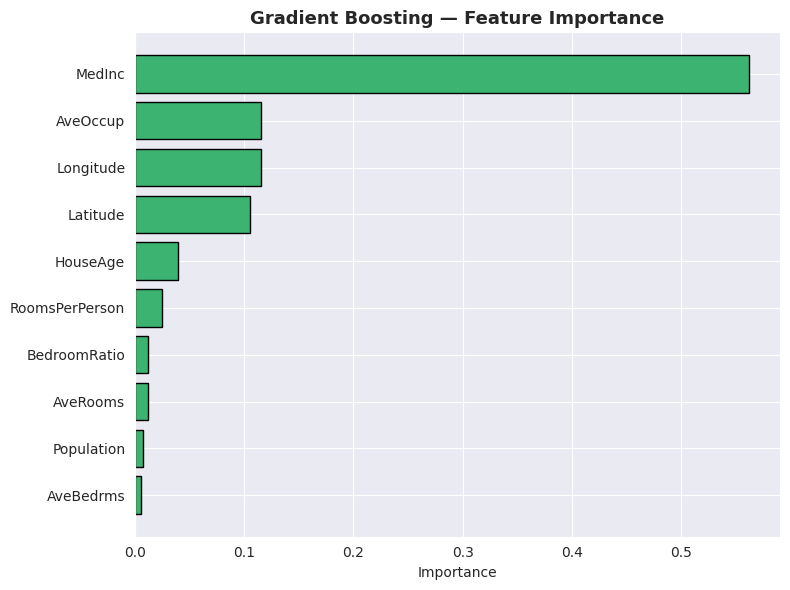

In [35]:
# Gradient Boosting feature importance
imp_df = pd.DataFrame({'Feature': feature_cols,
                        'Importance': gb.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(imp_df['Feature'], imp_df['Importance'],
         color='mediumseagreen', edgecolor='black')
plt.title('Gradient Boosting — Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

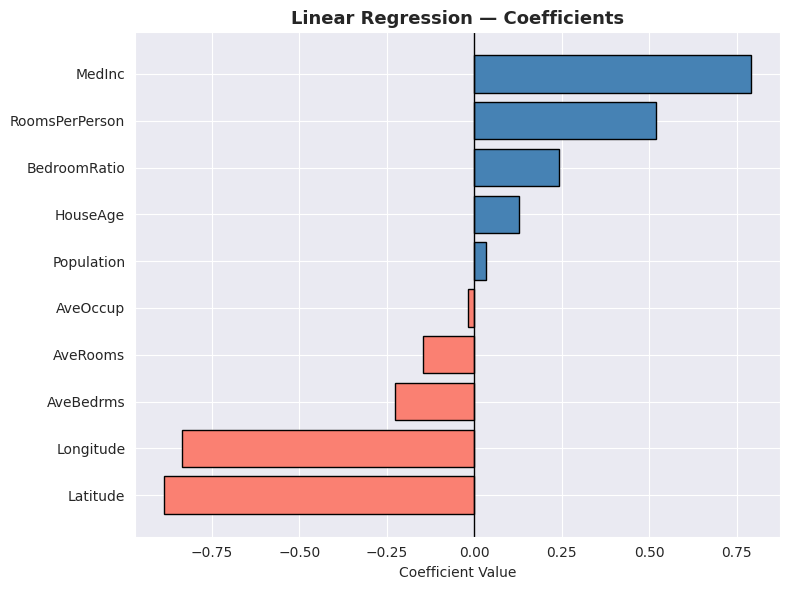

In [36]:
# Linear Regression coefficients
coef_df = pd.DataFrame({'Feature': feature_cols,
                         'Coefficient': lr.coef_})
coef_df = coef_df.sort_values('Coefficient')

plt.figure(figsize=(8, 6))
colors = ['salmon' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Linear Regression — Coefficients', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## Step 10: Conclusion

- **Linear Regression** provides a solid interpretable baseline but struggles with non-linear relationships.
- **Gradient Boosting** significantly outperforms Linear Regression (higher R², lower MAE/RMSE).
- **Most important features**: `MedInc` (median income), `Latitude`, `Longitude`, and `AveOccup`.
- **Negative coefficient for AveOccup** in LR shows that more occupants per room lowers predicted price.
- **Evaluation**: MAE tells us average dollar error; R² shows the variance explained by the model.
- **Next steps**: Try XGBoost or LightGBM, add polynomial features, or use a neural network for higher accuracy.